#### Lasso会把不重要的特征系数压缩到0,并只保留一项相关的特征,实现自动特征选择

#### 当数据维度增大时,只要无关变量与相关变量之间相关性不太强,Lasso的估计结果会趋近于模型选择的估计结果.但在存在相关特征的情况下,Lasso本身无法选出正确的稀疏模式.

In [1]:
import numpy as np
rng = np.random.RandomState(0)  # 独立的种子0的随机数生成器
n_samples, n_features, n_informative = 50, 100, 10
time_step = np.linspace(-2, 2, n_samples)
time_step

array([-2.        , -1.91836735, -1.83673469, -1.75510204, -1.67346939,
       -1.59183673, -1.51020408, -1.42857143, -1.34693878, -1.26530612,
       -1.18367347, -1.10204082, -1.02040816, -0.93877551, -0.85714286,
       -0.7755102 , -0.69387755, -0.6122449 , -0.53061224, -0.44897959,
       -0.36734694, -0.28571429, -0.20408163, -0.12244898, -0.04081633,
        0.04081633,  0.12244898,  0.20408163,  0.28571429,  0.36734694,
        0.44897959,  0.53061224,  0.6122449 ,  0.69387755,  0.7755102 ,
        0.85714286,  0.93877551,  1.02040816,  1.10204082,  1.18367347,
        1.26530612,  1.34693878,  1.42857143,  1.51020408,  1.59183673,
        1.67346939,  1.75510204,  1.83673469,  1.91836735,  2.        ])

In [2]:
freqs = 2 * np.pi * np.sort(rng.rand(n_features)) / 0.01  # rand均匀分布 [0,1)
X = np.zeros((n_samples, n_features))

for i in range(n_features):
    X[:, i] = np.sin(freqs[i] * time_step)

idx = np.arange(n_features)  # 0,1,...,99
true_coef = (-1) ** idx * np.exp(-idx / 10)
true_coef[n_informative:] = 0
y = np.dot(X, true_coef)

In [3]:
for i in range(n_features):
    X[:, i] = np.sin(freqs[i] * time_step + 2 * (rng.random_sample() - 0.5))
    X[:, i] += 0.2 * rng.normal(0, 1, n_samples)

y += 0.2 * rng.normal(0, 1, n_samples)

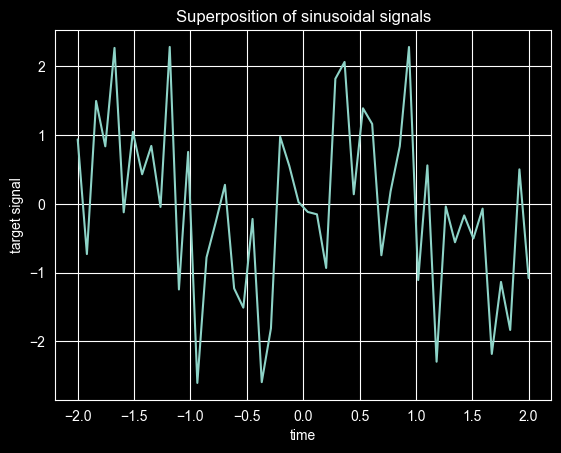

In [4]:
import matplotlib.pyplot as plt
plt.plot(time_step, y)
plt.ylabel("target signal")
plt.xlabel("time")
plt.title("Superposition of sinusoidal signals")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=False)

In [6]:
from time import time

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

t0 = time()
lasso = Lasso(alpha=0.14).fit(X_train, y_train)
print(f"Lasso fit done in {(time() - t0):.3f}s")

y_pred_lasso = lasso.predict(X_test)
r2_score_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso r^2 on test data : {r2_score_lasso:.3f}")

Lasso fit done in 0.001s
Lasso r^2 on test data : 0.480


In [7]:
from sklearn.linear_model import ARDRegression

t0 = time()
ard = ARDRegression().fit(X_train, y_train)
print(f"ARD fit done in {(time() - t0):.3f}s")

y_pred_ard = ard.predict(X_test)
r2_score_ard = r2_score(y_test, y_pred_ard)
print(f"ARD r^2 on test data : {r2_score_ard:.3f}")

ARD fit done in 0.027s
ARD r^2 on test data : 0.544


In [8]:
from sklearn.linear_model import ElasticNet

t0 = time()
enet = ElasticNet(alpha=0.08, l1_ratio=0.5).fit(X_train, y_train)
print(f"ElasticNet fit done in {(time() - t0):.3f}s")

y_pred_enet = enet.predict(X_test)
r2_score_enet = r2_score(y_test, y_pred_enet)
print(f"ElasticNet r^2 on test data : {r2_score_enet:.3f}")

ElasticNet fit done in 0.001s
ElasticNet r^2 on test data : 0.636


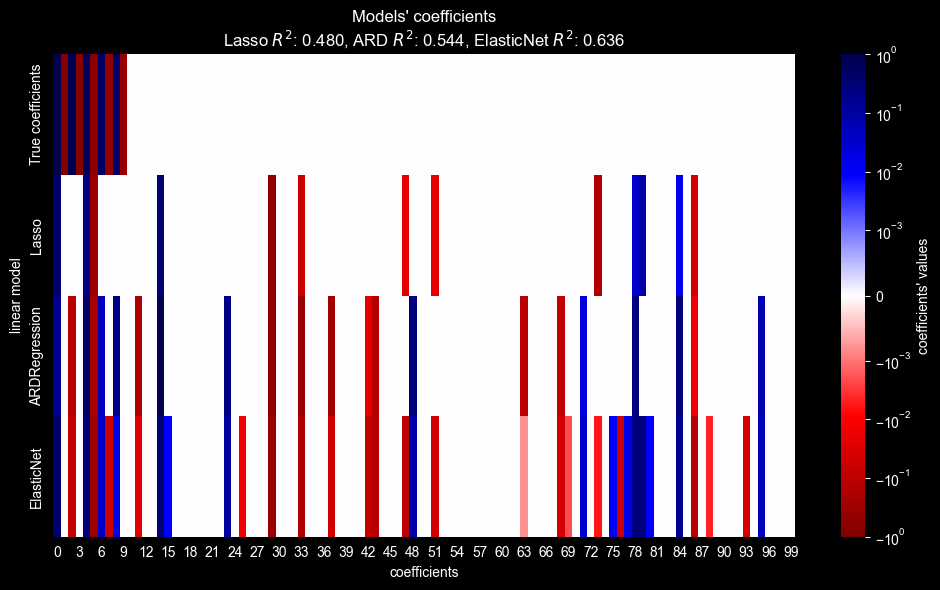

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import SymLogNorm

df = pd.DataFrame(
    {
        "True coefficients": true_coef,
        "Lasso": lasso.coef_,
        "ARDRegression": ard.coef_,
        "ElasticNet": enet.coef_,
    }
)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    df.T,
    norm=SymLogNorm(linthresh=10e-4, vmin=-1, vmax=1),
    cbar_kws={"label": "coefficients' values"},
    cmap="seismic_r",
)
plt.ylabel("linear model")
plt.xlabel("coefficients")
plt.title(
    f"Models' coefficients\nLasso $R^2$: {r2_score_lasso:.3f}, "
    f"ARD $R^2$: {r2_score_ard:.3f}, "
    f"ElasticNet $R^2$: {r2_score_enet:.3f}"
)
plt.tight_layout()

# 三种回归模型对比

## Lasso

- **优点**：能有效恢复稀疏数据
- **缺点**：特征高度相关时表现差，只会从相关组里随机选一个，其余系数压为0
- **适用**：稀疏且特征之间不相关的场景

---

## ElasticNet

- **行为**：系数既稀疏，又不会像 Lasso 那样对相关特征“只选一个”，而是把一组相关特征的权重都缩小但不一定归零
- **结果**：模型比 Lasso 更不稀疏（即非零系数更多），可能会保留一些非预测性特征
- **适用**：存在相关特征且它们共同对目标有贡献时

---

## ARDRegression

- **优点**：处理高斯噪声比前两者更好
- **缺点**：仍然无法处理相关特征，且因为要拟合先验分布，计算时间明显更长
- **定位**：噪声环境适用，但不解决特征相关性问题

## Lasso model selection: AIC-BIC / cross-validationm

In [5]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True, as_frame=True)  # return_X_y=True 直接返回特征矩阵和目标向量
print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [6]:
# 添加随机特征观察Lasso的特征选择能力
import numpy as np
import pandas as pd

rng = np.random.RandomState(42)
n_random_features = 14
X_random = pd.DataFrame(
    rng.randn(X.shape[0], n_random_features),  # X.shape返回元组,第一个是样本数,第二个是特征数
    columns=[f"random_{i:02d}" for i in range(n_random_features)]
)
X_random

,random_00,random_01,random_02,random_03,random_04,random_05,random_06,random_07,random_08,random_09,random_10,random_11,random_12,random_13
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280
1,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698
2,-0.600639,-0.291694,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,0.738467,0.171368
3,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280
4,-0.839218,-0.309212,0.331263,0.975545,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,1.356240,-0.072010,1.003533,0.361636,-0.645120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,0.551964,-0.344098,-0.114472,0.147756,-0.761825,0.210367,1.530335,-0.778095,1.171810,1.498098,-0.816155,-1.455055,0.301961,-0.547408
438,1.868603,0.034808,-0.802199,-1.147160,1.089905,-0.571184,0.043829,0.955803,-0.484258,-0.045929,-0.016568,0.683325,0.590744,-0.220114
439,0.063649,-0.371779,-1.477612,0.257601,1.892192,-0.883719,-0.773030,-0.870728,0.724592,0.448485,-0.158538,-0.918019,0.092377,-1.564622
440,0.143427,0.871524,-1.251199,-1.532518,1.579438,-0.611760,1.135948,-0.153998,-0.161955,0.438413,-0.883999,0.132497,-0.381489,-1.320493


In [7]:
X = pd.concat([X, X_random], axis=1)
X[X.columns[::3]].head()

,age,bp,s3,s6,random_02,random_05,random_08,random_11
0,0.038076,0.021872,-0.043401,-0.017646,0.647689,-0.234137,-0.469474,-0.465730
1,-0.001882,-0.026328,0.074412,-0.092204,-1.012831,-1.412304,0.067528,0.110923
2,0.085299,-0.005670,-0.032356,-0.025930,-0.601707,-1.057711,0.208864,0.196861
3,-0.089063,-0.036656,-0.036038,-0.009362,-1.478522,1.057122,0.324084,0.611676
4,0.005383,0.021872,0.008142,-0.046641,0.331263,-0.185659,0.812526,1.003533


In [9]:
import time
from sklearn.linear_model import LassoLarsIC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

start_time = time.time()
lasso_lars_ic = make_pipeline(StandardScaler(), LassoLarsIC(criterion="aic")).fit(X, y)
fit_time = time.time() - start_time
lasso_lars_ic

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('lassolarsic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {'aic', 'bic'}, default='aic'The type of criterion to use.",'aic'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"verbose verbose: bool or int, default=FalseSets the verbosity amount.",False
,"precompute precompute: bool, 'auto' or array-like, default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'


In [10]:
results = pd.DataFrame(
    {
        "alphas": lasso_lars_ic[-1].alphas_,
        "AIC criterion": lasso_lars_ic[-1].criterion_
    }
).set_index("alphas")
alpha_aic = lasso_lars_ic[-1].alpha_

In [13]:
lasso_lars_ic.set_params(lassolarsic__criterion="bic").fit(X, y)
results["BIC criterion"] = lasso_lars_ic[-1].criterion_
alpha_bic = lasso_lars_ic[-1].alpha_
results

,AIC criterion,BIC criterion
alphas,,
45.160030,5244.764779,5244.764779
42.300343,5208.250639,5212.341949
21.542052,4928.018900,4936.201520
15.034077,4869.678359,4881.952289
6.189631,4815.437362,4831.802601
5.329616,4810.423641,4830.880191
4.306012,4803.573491,4828.121351
4.124225,4804.126502,4832.765671
3.820705,4803.621645,4836.352124


In [16]:
def highlight_min(x):
    x_min = x.min()
    return ["font-weight:bold; background-color:yellow" if v==x_min else "" for v in x]

results.style.apply(highlight_min)  # apply是逐列传入

,AIC criterion,BIC criterion
alphas,,
45.160030,5244.764779,5244.764779
42.300343,5208.250639,5212.341949
21.542052,4928.018900,4936.201520
15.034077,4869.678359,4881.952289
6.189631,4815.437362,4831.802601
5.329616,4810.423641,4830.880191
4.306012,4803.573491,4828.121351
4.124225,4804.126502,4832.765671
3.820705,4803.621645,4836.352124


Text(0.5, 1.0, 'Information-criterion for model selection (training time 0.00s)')

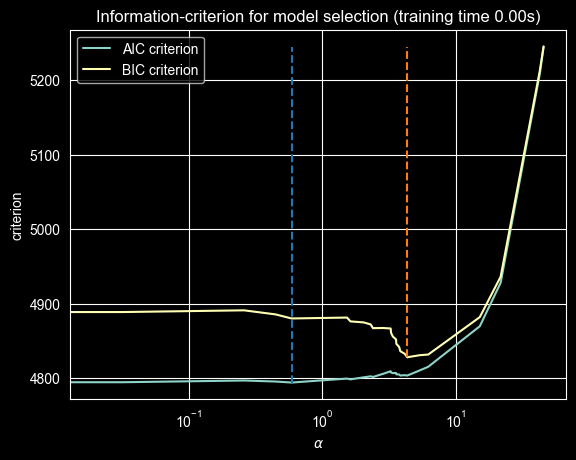

In [19]:
ax = results.plot()
ax.vlines(
    alpha_aic,
    results["AIC criterion"].min(),
    results["AIC criterion"].max(),
    label="alpha: AIC estimate",
    linestyle="--",
    color="tab:blue"
)
ax.vlines(
    alpha_bic,
    results["BIC criterion"].min(),
    results["BIC criterion"].max(),
    label="alpha: BIC estimate",
    linestyle="--",
    color="tab:orange"
)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel("criterion")
ax.set_xscale("log")
ax.set_title(f"Information-criterion for model selection (training time {fit_time:.2f}s)")

## BIC比AIC惩罚更严格,在大样本下不比AIC,二者都适用于低样本量环境

## 用LassoCV

In [20]:
from sklearn.linear_model import LassoCV

start_time = time.time()
model = make_pipeline(StandardScaler(), LassoCV(cv=20)).fit(X, y)
fit_time = time.time() - start_time

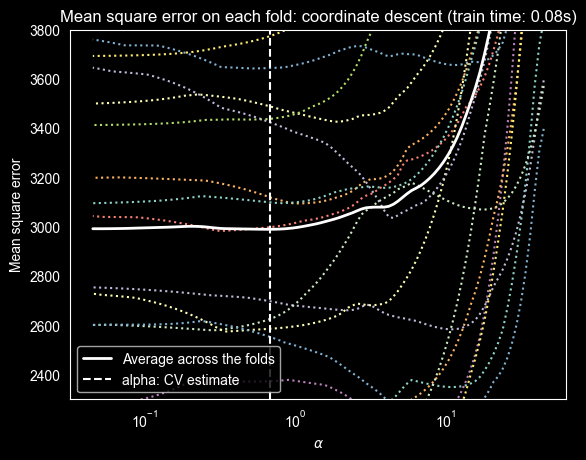

In [31]:
import matplotlib.pyplot as plt

ymin, ymax = 2300, 3800
lasso = model[-1]
plt.semilogx(lasso.alphas_, lasso.mse_path_, linestyle=":")
plt.plot(
    lasso.alphas_,
    lasso.mse_path_.mean(axis=-1),
    color="white",
    label="Average across the folds",
    linewidth=2,
)
plt.axvline(lasso.alpha_, linestyle="--", color="white", label="alpha: CV estimate")

plt.ylim(ymin, ymax)
plt.xlabel(r"$\alpha$")
plt.ylabel("Mean square error")
plt.legend()
plt.grid(False)  # 关闭网格线
_ = plt.title(
    f"Mean square error on each fold: coordinate descent (train time: {fit_time:.2f}s)"
)

## 用LassoLarsCV

In [32]:
from sklearn.linear_model import LassoLarsCV

start_time = time.time()
model = make_pipeline(StandardScaler(), LassoLarsCV(cv=20)).fit(X, y)
fit_time = time.time() - start_time

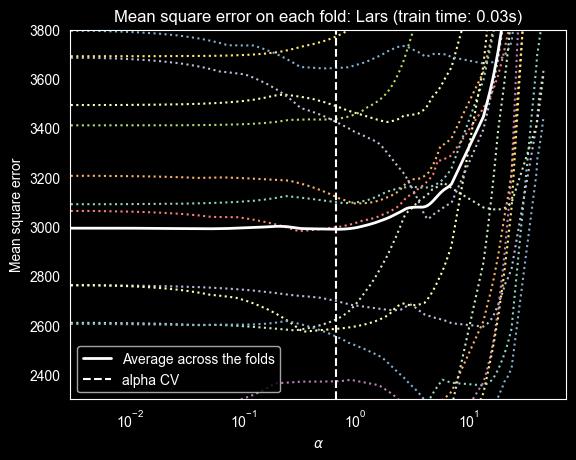

In [35]:
lasso = model[-1]
plt.semilogx(lasso.cv_alphas_, lasso.mse_path_, ":")
plt.semilogx(
    lasso.cv_alphas_,
    lasso.mse_path_.mean(axis=-1),
    color="white",
    label="Average across the folds",
    linewidth=2,
)
plt.axvline(lasso.alpha_, linestyle="--", color="white", label="alpha CV")

plt.ylim(ymin, ymax)
plt.xlabel(r"$\alpha$")
plt.ylabel("Mean square error")
plt.grid(False)
plt.legend()
_ = plt.title(f"Mean square error on each fold: Lars (train time: {fit_time:.2f}s)")

## LARS 与坐标下降算法对比及交叉验证选择 $\alpha$ 的说明

### 1. 算法对比：LARS vs 坐标下降

- **结果一致性**：两种算法给出的结果大致相同。

- **LARS 的特点**：
  - **计算路径**：只在路径的每个“拐点”（即系数进入或离开活跃集的位置）处计算解。
  - **高效场景**：当拐点数量很少时非常高效，这通常发生在特征或样本数量较少的情况下。
  - **无需网格**：不需要设置超参数（如 `alpha` 的候选值列表）就能计算出完整的解路径。

- **坐标下降的特点**：
  - **计算路径**：在一个**预先指定好**的网格点上计算解（例如 `np.logspace` 生成的 `alpha` 列表）。
  - **高效场景**：当网格点的数量少于路径的实际拐点数量时更高效。这在特征非常多、且交叉验证每一折都有足够样本时比较有用。

- **数值误差**：
  - 对于**高度相关**的特征，LARS 会积累更多误差。
  - 而坐标下降只在网格点上采样计算，误差特性不同。

---

### 2. 关于交叉验证选择 $\alpha$ 的说明

- **现象**：`lasso.mse_path_` 中每条折线的最低点对应的 `alpha` 可能不同（图中不同颜色的虚线的最低点位置不完全一样）。

- **结论**：这表明，通过交叉验证为模型选定的最优 `alpha`，在最终的未见测试集上**可能并不是最优的**。

- **应对方法**：应该使用**嵌套交叉验证**来更公正地评估模型的泛化性能（即内层选参数，外层评估模型）。

## 模型选择中 $\alpha$ 的两种优化策略对比

### 1. 信息准则法（AIC / BIC）
- **计算方式**：基于**训练集**拟合结果直接计算，无需划分验证集。
- **速度**：**非常快**，只需拟合一次模型。
- **原理**：在训练误差基础上加上模型复杂度惩罚项（$2k$ 或 $k\ln n$），估计泛化误差。
- **适用条件**：**样本量 $n$ 远大于特征数 $p$**，且假设模型正确（数据确实由该线性模型生成）。
- **注意**：小样本或模型错误时估计可能不准确。

### 2. 交叉验证法（Cross-Validation）
- **计算方式**：将数据划分为 $k$ 折，轮流用 $k-1$ 折训练、1 折验证，选择平均验证误差最小的 $\alpha$。
- **速度**：**较慢**，需要多次训练模型（$k$ 次）。
- **原理**：直接模拟模型在未见数据上的表现，不需要模型假设。
- **适用条件**：**通用**，适合高维数据（$p \gg n$）、小样本、特征相关等复杂情况。
- **注意**：计算量大，但结果更可靠。

---

### 综合结论

| 策略 | 速度 | 准确性前提 | 推荐场景 |
|------|------|------------|----------|
| AIC / BIC | 快（一次拟合） | $n \gg p$，模型正确 | 大样本、低维、探索性分析 |
| Cross-Validation | 慢（多次拟合） | 无强假设 | 高维、小样本、生产级模型 |

**最终建议**：
- 当样本量充足且相信线性假设时，**信息准则**可大幅节省时间。
- 在不确定数据生成过程或特征数较多时，**交叉验证**是更安全、更通用的选择。
- 实际应用中常用**交叉验证**作为基准，信息准则作为快速初筛。